### Preprocessing + TF-IDF Sentiment Classifier(Amazon Fine Food Reviews Dataset)

In [33]:

import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
    


In [34]:
#Load data
df = pd.read_csv("C:/Users/Priyanka/Datascience/NLP_projects/Reviews.csv")

#Take 30k samples from dataset for fast learning
df = df.sample(n=30000, random_state=42).reset_index(drop=True)
print(df[["Score","Summary","Text"]].head())
print("\n Score Distribution: ")
print(df['Score'].value_counts().sort_index())

   Score                                       Summary  \
0      5  Crunchy & Good Gluten-Free Sandwich Cookies!   
1      5                            great kitty treats   
2      3                                  COFFEE TASTE   
3      2              So the Mini-Wheats were too big?   
4      5                             Great Taste . . .   

                                                                                                                                                    Text  
0  Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture o...  
1  My cat loves these treats. If ever I can't find her in the house, I just pop the top and she bolts out of wherever she was hiding to come get a tr...  
2               A little less than I expected.  It tends to have a muddy taste - not what I expected since they said it was the favorite of the company.  
3  First there was Frosted Mini

In [35]:
#Label Creation
#1-2 =>Negative,3=>Neutral,4-5=>Positive
def score_to_sentiment(score):
    if score<=2:
        return "negative"
    elif score==3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(score_to_sentiment)
print("\nSentiment Distribution: ")
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True).round(3))
    
    



Sentiment Distribution: 
sentiment
positive    23423
negative     4306
neutral      2271
Name: count, dtype: int64
sentiment
positive    0.781
negative    0.144
neutral     0.076
Name: proportion, dtype: float64


In [36]:
#Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"http\S+|www\S+", " ",text)
    text = re.sub(r"[^a-z\s]"," ",text)
    text = re.sub(r"\s+", " ",text).strip()
    return text
    
print("\nCleaning Text")
df["clean_text"] = df["Text"].apply(clean_text)




Cleaning Text


In [37]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(df["clean_text"],df["sentiment"],
                                                    test_size=0.2,random_state=42, stratify=df["sentiment"])

In [38]:
#TF-IDF + Logistic Regression

print("\n Vectorizing with TF-IDF")
vectorizer = TfidfVectorizer(max_features=1000,ngram_range=(1,2),stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nLogistic Regression")
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_tfidf,y_train)


 Vectorizing with TF-IDF

Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
#Evaluation

y_pred = clf.predict(X_test_tfidf)
print("\n=================================")
print("\n Classification Report:")
print("\n=================================")
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["negative","neutral","positive"])
print("Confusion Matrix(rows=actual, cols=predicted):")
print(pd.DataFrame(cm, index=["neg","neu","pos"], columns=["neg","neu","pos"]))


      



 Classification Report:

              precision    recall  f1-score   support

    negative       0.49      0.66      0.56       861
     neutral       0.19      0.50      0.27       454
    positive       0.95      0.73      0.83      4685

    accuracy                           0.71      6000
   macro avg       0.54      0.63      0.55      6000
weighted avg       0.82      0.71      0.75      6000

Confusion Matrix(rows=actual, cols=predicted):
     neg  neu   pos
neg  569  189   103
neu  134  227    93
pos  453  791  3441


In [40]:
#Error Analysis
#Look at reviews the model got wrong
results= pd.DataFrame({
    "text" : X_test.values,
    "actual" :y_test.values,
    "predicted" : y_pred})

misclassified = results[results["actual"]!=results["predicted"]]
print(f"\n {len(misclassified)}/len{(results)} misclassified({len(misclassified)/len(results):.1%})")
print("\n Sample Missclassifications:")
pd.set_option("display.max_colwidth",150)
print(misclassified.sample(min(10,len(misclassified)),random_state=1)[["text","actual","predicted"]])


 1763/len                                                                                                                                                       text  \
0     after trying the lb bag of go grain free endurance and watching my border collie s skin allergy problem begin to disappear this had to be one of t...   
1     i use a ton okay exaggerated of this vanilla powder lattes tea coffee baking oatmeal cold cereal anywhere you want that sweet floral goodness that...   
2     these are the best chocolate chips i ve ever tasted in my life yes they are pricey but it doesn t matter because they last forever and you use abo...   
3     i thought the coffee tasted fine it was not strong enough for my husband several of the pods burst during brewing i probably won t purchase this a...   
4                                   this has got to be the best black licorice in the world as i consider myself quite the connoisseur of this fine product   
...                                 

In [41]:
#save misclassified examples
misclassified.to_csv("missclassified.csv", index=False)


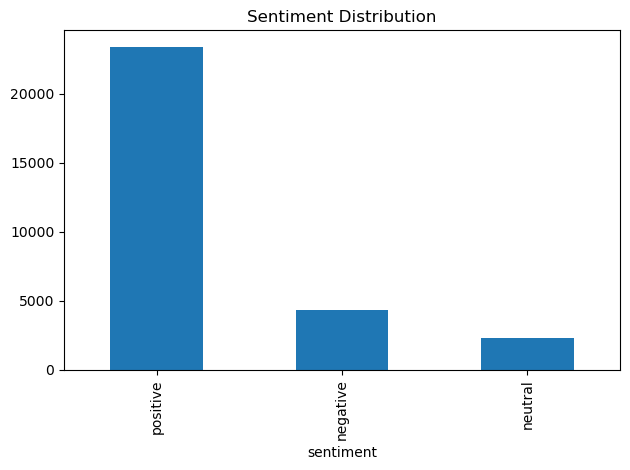

In [42]:
#Visual
df["sentiment"].value_counts().plot(kind="bar",title="Sentiment Distribution")
plt.tight_layout()
plt.savefig("sentiment_distribution.png")
plt.show()


In [43]:
#save cleaned dataframe
df.to_csv("cleaned_data.csv", index=False)